# Category-Stratified AUC Analysis

Supplementary Experiment 1 for *Computational Economics* manuscript.

**Goal**: Test whether TDA indicator (Betti-0) discriminatory power varies
across event categories, and compare against financial baselines per category.

In [1]:
from pathlib import Path
from datetime import timedelta
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import roc_curve, auc as sklearn_auc

DATA_PATH = Path('/Users/jane/Documents/202511吾-Systems/3.Data/TDA_SP500_VIX_BTC_BVOL_CVI_merged0329_labeled_with_network.csv')
DATA_OUT  = Path('/Users/jane/Documents/202511吾-Systems/12.Data0329')
DATA_OUT.mkdir(parents=True, exist_ok=True)

EVENT_CATALOG = [
    ('2020-12-01','Protocol/Tech',         'Ethereum 2.0'),
    ('2021-01-02','Market Milestone',       'BTC $30k'),
    ('2021-01-07','Market Milestone',       'BTC $40k'),
    ('2021-01-29','Market Milestone',       'Dogecoin frenzy'),
    ('2021-02-16','Market Milestone',       'BTC $50k'),
    ('2021-03-13','Market Milestone',       'BTC $60k'),
    ('2021-04-10','Market Milestone',       'BTC peak'),
    ('2021-05-12','Corporate Action',       'Musk BTC suspend'),
    ('2021-05-17','Corporate Action',       'Musk tweet'),
    ('2021-05-18','Corporate Action',       'Musk clarifies'),
    ('2021-05-19','Regulation',             'China crackdown'),
    ('2021-06-09','Regulation',             'El Salvador'),
    ('2021-09-24','Regulation',             'China ban'),
    ('2021-10-15','Institutional Adoption', 'US BTC ETF'),
    ('2021-11-15','Regulation',             'US Infra Bill'),
    ('2022-04-27','Regulation',             'CAR BTC'),
    ('2022-05-01','Systemic Failure',       'UST depeg'),
    ('2022-05-11','Systemic Failure',       'UST collapse'),
    ('2022-05-12','Systemic Failure',       'Terra collapse'),
    ('2022-05-13','Systemic Failure',       'Luna delisting'),
    ('2022-07-20','Corporate Action',       'Tesla sells BTC'),
    ('2022-11-01','Systemic Failure',       'FTX collapse'),
    ('2023-03-01','Systemic Failure',       'SVB stress'),
    ('2023-03-10','Systemic Failure',       'USDC depeg'),
    ('2023-05-17','Corporate Action',       'Tether buys BTC'),
    ('2023-06-16','Institutional Adoption', 'BlackRock ETF'),
    ('2023-07-01','Security/Hack',          'DeFi hacks'),
    ('2023-10-01','Regulation',             'Grayscale'),
    ('2024-03-19','Institutional Adoption', 'Japan GPIF'),
    ('2024-04-20','Protocol/Tech',          'BTC halving'),
    ('2025-01-20','Regulation',             'Trump inaug.'),
    ('2025-02-03','Macro Shock',            'AI/tariff shock'),
    ('2025-02-21','Security/Hack',          'Bybit hack'),
    ('2025-03-07','Regulation',             'BTC Reserve'),
    ('2025-05-20','Regulation',             'Stablecoin Bill'),
    ('2025-06-05','Institutional Adoption', 'Circle IPO'),
    ('2025-06-17','Regulation',             'GENIUS Act'),
]
events_df = pd.DataFrame(EVENT_CATALOG, columns=['date','category','event'])
events_df['date'] = pd.to_datetime(events_df['date'])

CAT_COLORS = {
    'Regulation':            '#E64B35',
    'Market Milestone':      '#4DBBD5',
    'Systemic Failure':      '#F39B7F',
    'Corporate Action':      '#91D1C2',
    'Institutional Adoption':'#3C5488',
    'Protocol/Tech':         '#00A087',
    'Macro Shock':           '#8491B4',
    'Security/Hack':         '#B09C85',
}
CATS_ORDERED = ['Regulation','Systemic Failure','Market Milestone',
                'Institutional Adoption','Corporate Action',
                'Protocol/Tech','Macro Shock','Security/Hack']
TDA_COLS  = ['log_dtw_betti0','log_wass_betti0','vol_dtw_betti0','vol_wass_betti0']
BASE_COLS = ['VIX','BVOL','SP500','fng_value','vol_btc_rogers']
ALL_INDS  = TDA_COLS + BASE_COLS
WINDOW    = 21
print(f'Events: {len(events_df)} | Categories: {events_df.category.nunique()}')


Events: 37 | Categories: 8


In [2]:
df = pd.read_csv(DATA_PATH)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
for c in ['VIX','BVOL','SP500']:
    df[c] = df[c].ffill()

def compute_auc(y_true, y_score):
    s = pd.to_numeric(y_score, errors='coerce').to_numpy()
    m = np.isfinite(s)
    if m.sum()==0 or np.unique(y_true[m]).size<2: return np.nan
    fpr, tpr, _ = roc_curve(y_true[m], s[m])
    a = sklearn_auc(fpr, tpr)
    return max(a, 1-a)

auc_rows = []
for cat in CATS_ORDERED:
    cat_events = events_df[events_df['category']==cat]['date'].tolist()
    label = np.zeros(len(df), dtype=int)
    for e in cat_events:
        label[(df['date'] >= e-timedelta(days=WINDOW)) & (df['date'] <= e)] = 1
    if label.sum()==0: continue
    for ind in ALL_INDS:
        a = compute_auc(label, df[ind])
        auc_rows.append({'category':cat,'indicator':ind,
                         'type':'TDA' if ind in TDA_COLS else 'Baseline',
                         'n_events':len(cat_events),'auc':round(a,4)})

auc_cat = pd.DataFrame(auc_rows)
auc_cat.to_csv(DATA_OUT/'tbl_auc_by_event_category.csv', index=False)

best = (auc_cat.groupby(['category','type'])['auc'].max()
        .unstack('type').reindex(CATS_ORDERED).reset_index())
best['TDA Advantage'] = (best['TDA'] - best['Baseline']).round(4)
best['n_events'] = best['category'].map(events_df.groupby('category').size())
best.to_csv(DATA_OUT/'tbl_best_auc_by_category.csv', index=False)
display(best)


type,category,Baseline,TDA,TDA Advantage,n_events
0,Regulation,0.6532,0.5688,-0.0844,10
1,Systemic Failure,0.8024,0.6021,-0.2003,7
2,Market Milestone,0.9470,0.9738,0.0268,6
3,Institutional Adoption,0.6518,0.5773,-0.0745,4
4,Corporate Action,0.7398,0.5538,-0.1860,5
5,Protocol/Tech,0.8946,0.7380,-0.1566,2
6,Macro Shock,0.9287,0.6150,-0.3137,1
7,Security/Hack,0.8064,0.6980,-0.1084,2


/var/folders/np/ry82r7v95y33d2df6jpjnr4c0000gn/T/ipykernel_12812/2485231097.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


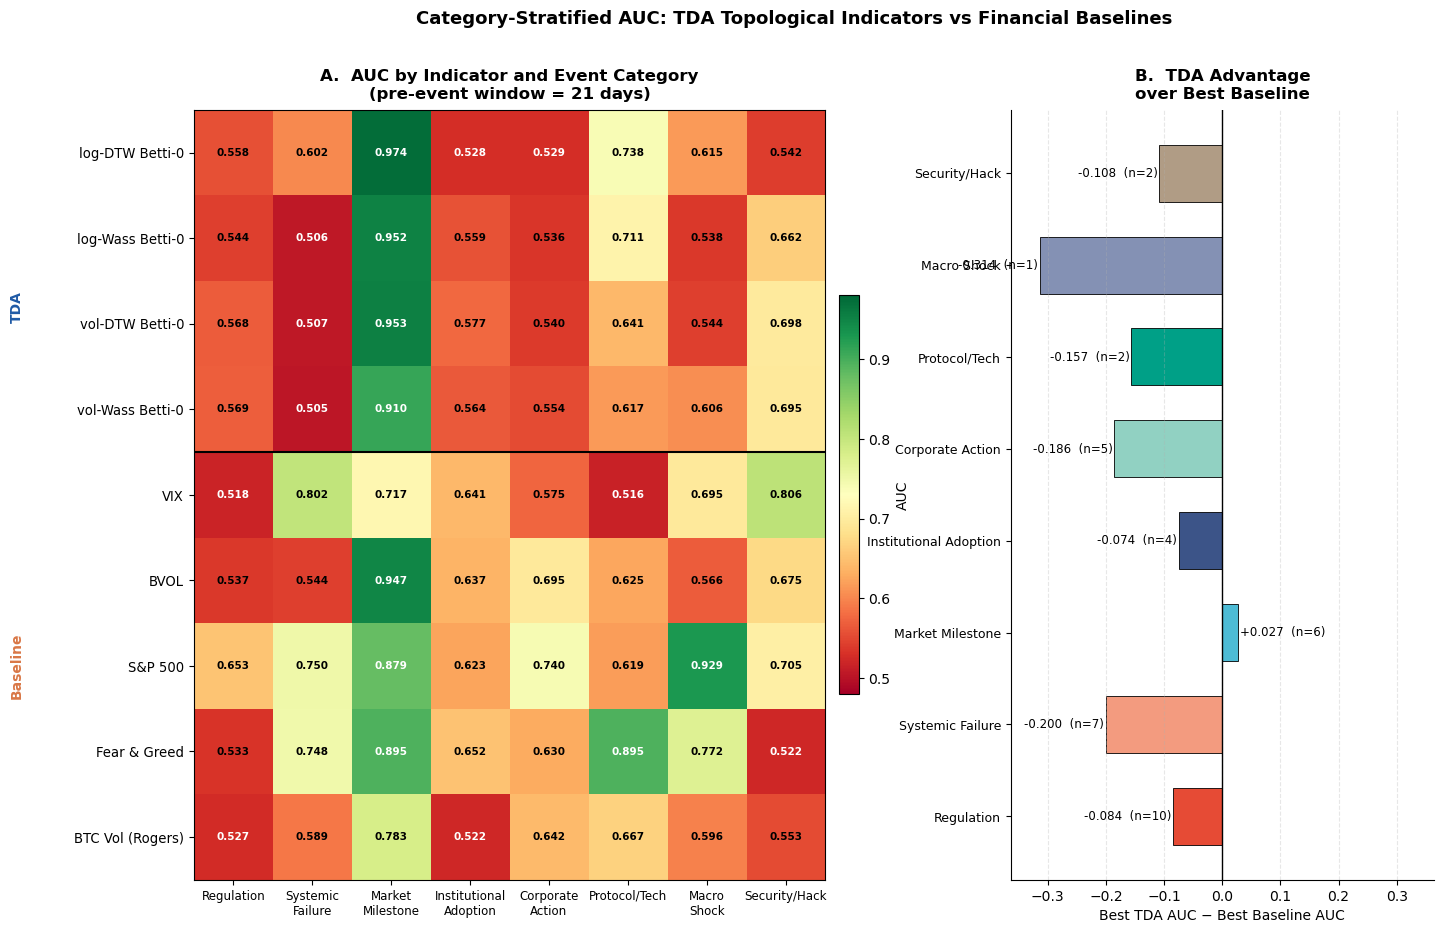

Saved.


In [3]:
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(1, 2, figure=fig, width_ratios=[2.2, 1.4], wspace=0.28)
ax_heat = fig.add_subplot(gs[0])
ax_bar  = fig.add_subplot(gs[1])

pivot = (auc_cat.pivot_table(index='indicator', columns='category', values='auc')
         .reindex(columns=CATS_ORDERED).reindex(ALL_INDS))

row_labels = {
    'log_dtw_betti0':'log-DTW Betti-0','log_wass_betti0':'log-Wass Betti-0',
    'vol_dtw_betti0':'vol-DTW Betti-0','vol_wass_betti0':'vol-Wass Betti-0',
    'VIX':'VIX','BVOL':'BVOL','SP500':'S&P 500',
    'fng_value':'Fear & Greed','vol_btc_rogers':'BTC Vol (Rogers)',
}
vals = pivot.values
im = ax_heat.imshow(vals, cmap='RdYlGn', vmin=0.48, vmax=0.98, aspect='auto')
plt.colorbar(im, ax=ax_heat, fraction=0.03, pad=0.02, label='AUC')
ax_heat.set_xticks(range(len(CATS_ORDERED)))
ax_heat.set_xticklabels([c.replace(' ','\n') for c in CATS_ORDERED], fontsize=8.5)
ax_heat.set_yticks(range(len(ALL_INDS)))
ax_heat.set_yticklabels([row_labels[i] for i in ALL_INDS], fontsize=9.5)
ax_heat.axhline(3.5, color='black', linewidth=1.5)
for i in range(len(ALL_INDS)):
    for j in range(len(CATS_ORDERED)):
        v = vals[i,j]
        if np.isnan(v): continue
        ax_heat.text(j, i, f'{v:.3f}', ha='center', va='center',
                     fontsize=7.5, color='white' if (v>0.85 or v<0.53) else 'black',
                     fontweight='bold')
ax_heat.text(-0.28, 1.8, 'TDA', transform=ax_heat.get_yaxis_transform(),
             ha='center', va='center', fontsize=10, color='#1f5aa6', fontweight='bold', rotation=90)
ax_heat.text(-0.28, 6.0, 'Baseline', transform=ax_heat.get_yaxis_transform(),
             ha='center', va='center', fontsize=10, color='#d97746', fontweight='bold', rotation=90)
ax_heat.set_title('A.  AUC by Indicator and Event Category\n(pre-event window = 21 days)',
                  fontsize=12, fontweight='bold', pad=8)

best_plot = best.dropna(subset=['TDA','Baseline'])
y = np.arange(len(best_plot))
gaps = best_plot['TDA Advantage'].values
bar_colors = [CAT_COLORS[c] for c in best_plot['category']]
ax_bar.barh(y, gaps, color=bar_colors, edgecolor='black', linewidth=0.6, height=0.62)
ax_bar.axvline(0, color='black', linewidth=1.0)
for yi, (v, row) in enumerate(zip(gaps, best_plot.itertuples())):
    sign = '+' if v>=0 else ''
    ax_bar.text(v+(0.003 if v>=0 else -0.003), yi,
                f'{sign}{v:.3f}  (n={int(row.n_events)})',
                va='center', ha='left' if v>=0 else 'right', fontsize=8.5)
ax_bar.set_yticks(y)
ax_bar.set_yticklabels(best_plot['category'], fontsize=9)
ax_bar.set_xlabel('Best TDA AUC − Best Baseline AUC', fontsize=10)
ax_bar.set_title('B.  TDA Advantage\nover Best Baseline', fontsize=12, fontweight='bold', pad=8)
ax_bar.xaxis.grid(True, linestyle='--', alpha=0.3)
ax_bar.spines['top'].set_visible(False); ax_bar.spines['right'].set_visible(False)
xmax = max(abs(gaps[np.isfinite(gaps)]).max()+0.05, 0.12)
ax_bar.set_xlim(-xmax, xmax)
fig.suptitle('Category-Stratified AUC: TDA Topological Indicators vs Financial Baselines',
             fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig(DATA_OUT/'fig_auc_by_event_category.png', dpi=300, bbox_inches='tight')
fig.savefig(DATA_OUT/'fig_auc_by_event_category.pdf', bbox_inches='tight')
plt.show(); print('Saved.')
